In [1]:
path = '/home/user/Desktop/diploma'

In [2]:
import sys
import sqlite3
import pandas as pd
import re
import glob
import numpy as np
import json
import os

sys.path.append(os.path.abspath(path+'/results'))
from utils import evaluate_cf, plot_attack_comparison, plot_size_comparison

sys.path.append(os.path.abspath(path+'/eraserbenchmark-master'))
from rationale_benchmark.utils import load_documents, annotations_from_jsonl

# load data

In [3]:
data_root = os.path.join(path, 'eraserbenchmark-master', 'data', 'esnli')
esnli_docs = load_documents(data_root)
esnli = annotations_from_jsonl(os.path.join(data_root, 'test.jsonl'))
esnli[:] = [instance for instance in esnli if instance.classification != 'neutral']

In [4]:
def collect_df(model, path, esnli):
    """
    Collect results for all prompt-engineering variants (including combined ones)
    and store each variant as its own column.
    """

    # Initialize main DataFrame with test-level info
    resDf = pd.DataFrame()
    os.chdir(path + '/eraserbenchmark-master/esnli_dataset_builder/my_dataset')
    resDf['texts'] = pd.read_csv("test.csv")['sentence2']

    resDf['evidence_ranges'] = [
            [(ev.start_token, ev.end_token)
             for ev in next(iter(instance.evidences))
             if '_premise' in ev.docid and ev.docid.endswith('_premise')]
            for instance in esnli
        ]
    

    # Load CREST rationales from saved file
    crest_data_path = os.path.join(path, "results/crest/processed_e_snli_rationales.csv")
    crest_df = pd.read_csv(crest_data_path)
    resDf['crest_rationales'] = crest_df['word_rationales'].apply(lambda x: [int(i) for i in eval(x)]).tolist()
    
    
    base_dir = os.path.join(path, "introspections/results/analysis")
    os.chdir(base_dir)              

    # Find all .sqlite result files
    sqlite_files = glob.glob(f'analysis_m-{model}_y-none_d-rte_p-test_t-counterfactual_*.sqlite')

    for file in sqlite_files:
        # Extract everything after c- and before _s-
        variant = file.split("c-")[-1].split("_s-")[0].strip('-')
        if variant == "" or variant == "_":
            variant = "baseline"

        # Normalize spacing and dashes in case of multiple prompt flags
        variant = variant.replace(' ', '-').strip()

        conn = sqlite3.connect(file)
        cursor = conn.cursor()
        cursor.execute("SELECT debug, explain, correct, faithful FROM Counterfactual;")
        df = pd.DataFrame(cursor.fetchall(), columns=['texts', 'selfexp', 'correct', 'faithful'])
        conn.close()

        # Add this variant as its own column
        resDf[variant] = df.apply(
            lambda row: {
                'selfexp': row['selfexp'],
                'correct': row['correct'],
                'faithful': row['faithful']
            },
            axis=1
        )

    # Load attack results
    os.chdir(path)
    csv_files = glob.glob(os.path.join("attacks/esnli_attacks", f"{model}*"))
    for file in csv_files:
        df = pd.read_csv(file)
        attack_name = file.split('_')[-1].replace(".csv", "")
        resDf[attack_name] = df.apply(
            lambda row: {
                'perturbed_text': row['perturbed_text'],
                'result_type': row['result_type'],
                'original_score': row['original_score'],
                'perturbed_score': row['perturbed_score']
            },
            axis=1
        )

    return resDf

In [ ]:
# Process models in smaller batches to avoid memory issues
models = ['llama3-1b','llama3-3b','llama3-8b','llama3-70b','qwen-1b','qwen-3b','qwen-7b','qwen-14b','qwen-32b','qwen-72b']

dataframes = {}

print("Starting data collection...")
for i, model in enumerate(models):
    print(f"Collecting data for {model} ({i+1}/{len(models)})...")
        
    df = collect_df(model, path, esnli)
    dataframes[model] = df

print("Data collection complete.")

Starting data collection...
Data collection complete.


# Evaluation

In [7]:
def evaluate_df(df):
    results = []

    # Identify different types of columns
    base_cols = ['texts', 'evidence_ranges', 'crest_rationales']
    prompt_columns = [col for col in df.columns if col not in base_cols and isinstance(df[col].iloc[0], dict) and 'selfexp' in df[col].iloc[0]]
    attack_columns = [col for col in df.columns if col not in base_cols + prompt_columns]

    # ---- Evaluate counterfactuals for each prompt variant ----
    for index, row in df.iterrows():
        print(index, end="\r", flush=True)
        row_result = {}

        for prompt_col in prompt_columns:
            if row[prompt_col] is not None and 'selfexp' in row[prompt_col]:
                selfexp = row[prompt_col]['selfexp']
                faithfulness = int(row[prompt_col]['faithful']) if not pd.isna(row[prompt_col]['faithful']) else 0
                if selfexp is not None:
                    if faithfulness == 1:
                        row_result[prompt_col] = evaluate_cf(
                            row['texts'],
                            row['evidence_ranges'],
                            row['crest_rationales'],
                            selfexp
                        )
                    else:
                      row_result[prompt_col] = None

        # ---- Evaluate attacks ----
        for attack_col in attack_columns:
            if row[attack_col]['result_type'] == 'Successful':
                attacked_text = row[attack_col]['perturbed_text'].split('.')[1]
                attacked_text = re.sub(r"\[\[(.*?)\]\]", lambda m: m.group(1), attacked_text)
                row_result[attack_col] = evaluate_cf(row['texts'], row['evidence_ranges'], row['crest_rationales'], attacked_text)
            else:
                row_result[attack_col] = None
        results.append(row_result)

    # ---- Summaries ----
    summaries = {}

    # Prompt variant success (faithful)
    for prompt_col in prompt_columns:
        total = len(df)
        faithful = sum(
            int(row[prompt_col]['faithful']  if not pd.isna(row[prompt_col]['faithful']) else 0)
            for _, row in df.iterrows()
            if row[prompt_col] is not None and 'faithful' in row[prompt_col]
        )
        summaries[prompt_col] = {'successful': faithful, 'total': total}

    # Attack success rates
    for attack_col in attack_columns:
        successful = 0
        total = 0
        for _, row in df.iterrows():
            total += 1
            if row[attack_col]['result_type'] == 'Successful':
                successful += 1
        summaries[attack_col] = {'successful': successful, 'total': total}

    return pd.DataFrame(results), summaries

In [ ]:
os.chdir(path + '/results/esnli_results/results_dataframes')

print("Evaluation started...")

models = ['qwen-1b','qwen-3b','qwen-7b','qwen-14b','qwen-32b','qwen-72b']

for i, model in enumerate(models):
    print(f"Evaluating {model} ({i+1}/{len(models)})...")
    
    df = dataframes[model]
    res, attack_res = evaluate_df(df)

    csv_path = f"{model}_res.csv"
    res.to_csv(csv_path, index=False)

    json_path = f"{model}_attack_res.json"
    with open(json_path, "w") as f:
        json.dump(attack_res, f, indent=4)

    print(f"Finished {model}: saved {csv_path} and {json_path}")


print("All evaluations completed.")

Evaluation started...
Evaluating qwen-1b (1/6)...
  GPU memory before qwen-1b: 4.91 GB allocated
  GPU memory before qwen-1b: 4.91 GB allocated


OutOfMemoryError: CUDA out of memory. Tried to allocate 198.00 MiB. GPU 0 has a total capacity of 5.79 GiB of which 53.19 MiB is free. Including non-PyTorch memory, this process has 5.69 GiB memory in use. Of the allocated memory 5.45 GiB is allocated by PyTorch, and 134.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

LOAD THE RESULTS

In [3]:
os.chdir(path + '/results/esnli_results/results_dataframes')

# Columns in the DataFrames that contain dicts
dict_columns = [
    'baseline', 'e-implcit-target-e-persona-human', 'e-persona-you',
    'e-implcit-target-e-persona-you', 'e-implcit-target', 'e-persona-human', 'TextFoolerJin2019'
]

# Function to safely convert np.float32 to float in a dict
def convert_dict(d):
    if isinstance(d, dict):
        return {k: float(v) if isinstance(v, (np.float32, np.float64)) else v for k, v in d.items()}
    return d

# Function to safely evaluate string representations
def safe_eval(x):
    if pd.isna(x) or x is None or (isinstance(x, str) and (x.strip().lower() == 'nan' or x.strip() == '')):
        return None
    if isinstance(x, str):
        try:
            import ast
            return ast.literal_eval(x.strip())
        except:
            try:
                return eval(x.strip())
            except:
                return None
    return x

# Function to load a CSV with dict columns
def load_result_csv(csv_path):
    df = pd.read_csv(csv_path)
    for col in dict_columns:
        if col in df.columns:
            df[col] = df[col].apply(safe_eval).apply(convert_dict)
    return df

# Function to load a JSON attack file
def load_attack_json(json_path):
    with open(json_path, "r") as f:
        return json.load(f)

# Load results and attacks
results = {}
attacks = {}
models = ['llama3-1b','llama3-3b','llama3-8b','llama3-70b','qwen-1b','qwen-3b','qwen-7b','qwen-14b','qwen-32b','qwen-72b']

for model in models:
    results[model] = load_result_csv(f"{model}_res.csv")
    attacks[model] = load_attack_json(f"{model}_attack_res.json")

# Introspection - Attack Evaluation
**Success rate**: the percentage of input instances for which the model was able to generate a faithful counterfactual — a perturbed version of the input that leads the model to predict the opposite label compared to the original classification.

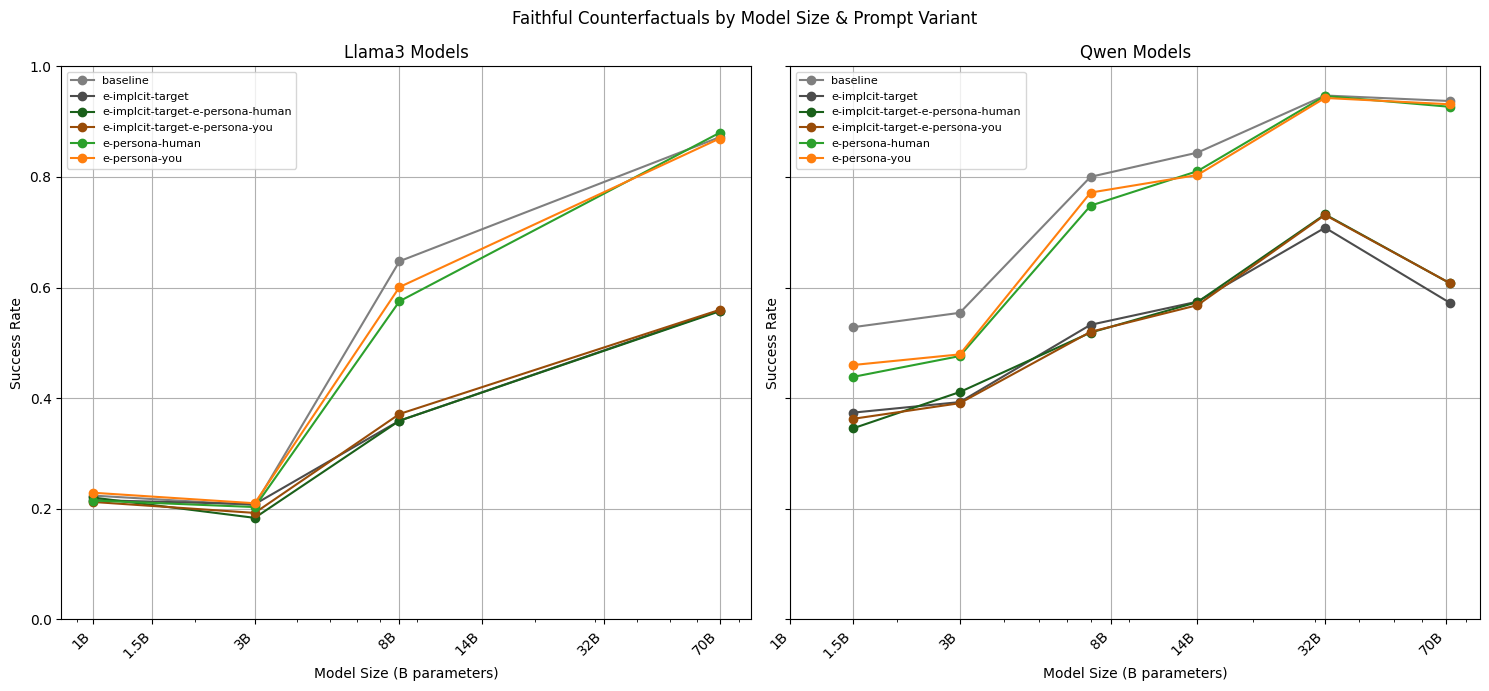

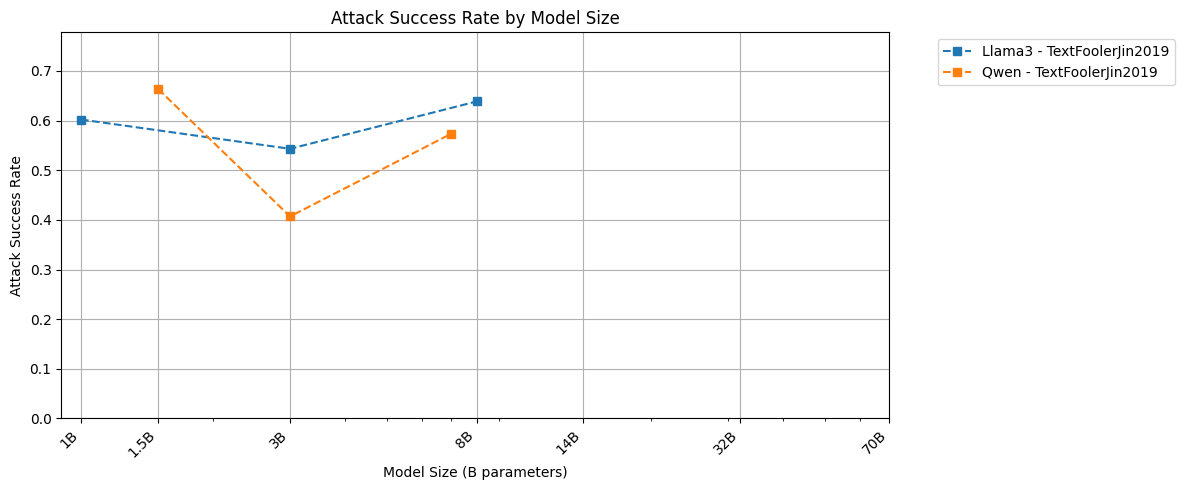

In [4]:
plot_dir = path + '/results/esnli_results/plots'
plot_attack_comparison(models, attacks, plot_dir)

# Counterfactual Evaluation Metrics

Metric groups detected:
  • closeness
  • semantic_similarity
  • contradiction
  • fluency
  • diversity
  • evidence_accuracy
  • evidence_precision
  • evidence_recall
  • evidence_f1
  • crest_accuracy
  • crest_precision
  • crest_recall
  • crest_f1

🔹 Processing metric group: closeness
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/closeness_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/closeness_Introspection_Llama3.png


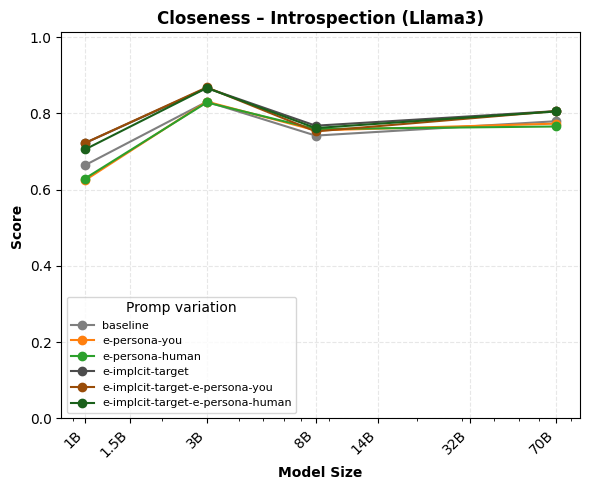

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/closeness_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/closeness_Introspection_Qwen.png


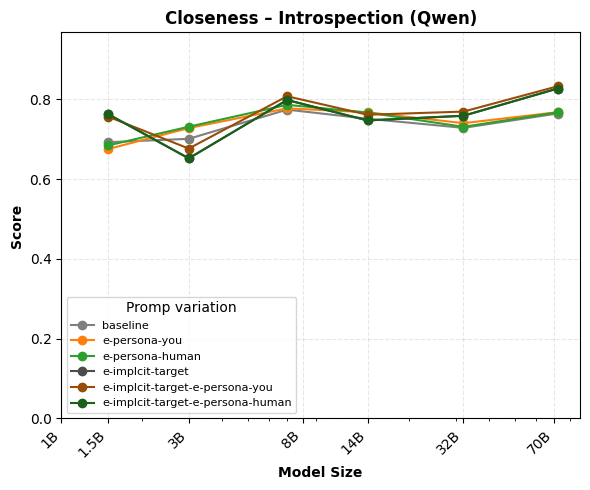

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/closeness_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/closeness_TextFooler.png


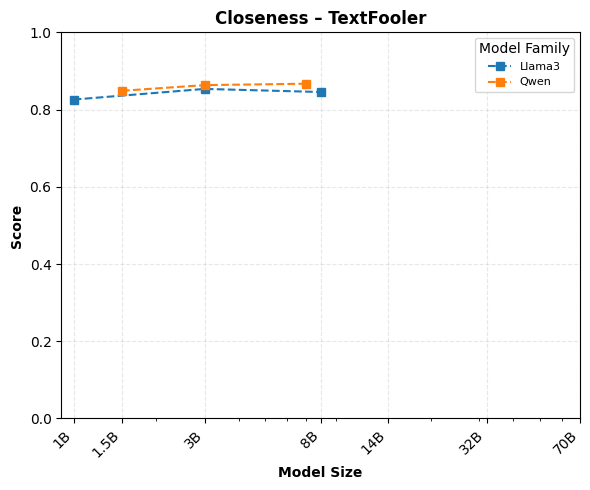


🔹 Processing metric group: semantic_similarity
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/semantic_similarity_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/semantic_similarity_Introspection_Llama3.png


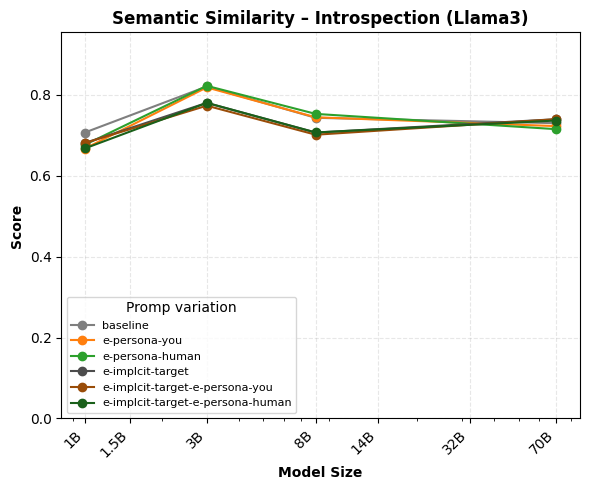

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/semantic_similarity_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/semantic_similarity_Introspection_Qwen.png


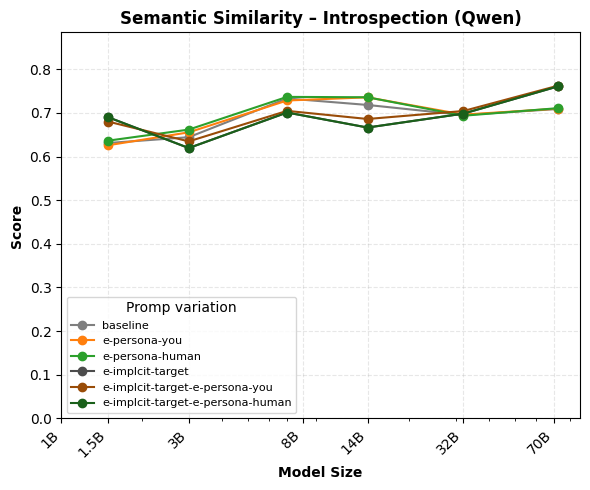

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/semantic_similarity_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/semantic_similarity_TextFooler.png


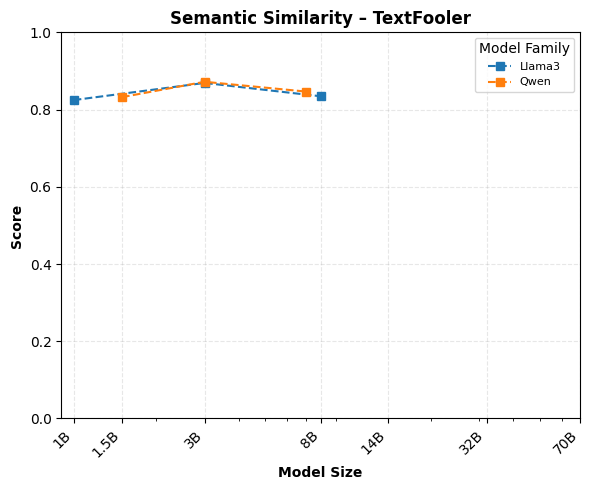


🔹 Processing metric group: contradiction
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/contradiction_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/contradiction_Introspection_Llama3.png


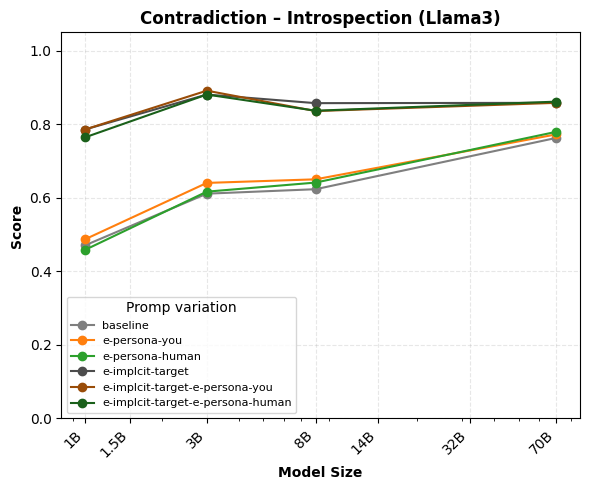

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/contradiction_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/contradiction_Introspection_Qwen.png


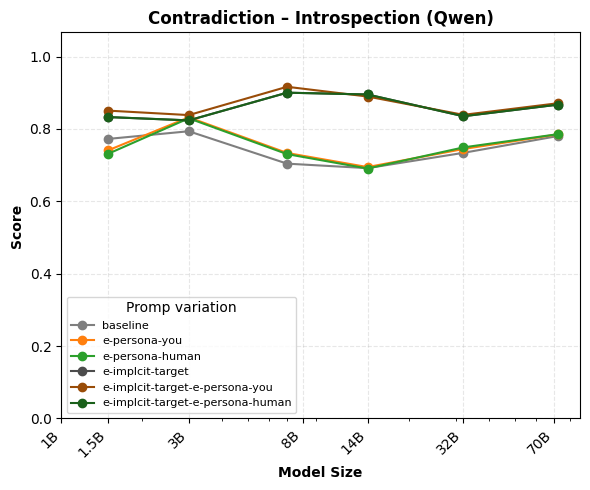

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/contradiction_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/contradiction_TextFooler.png


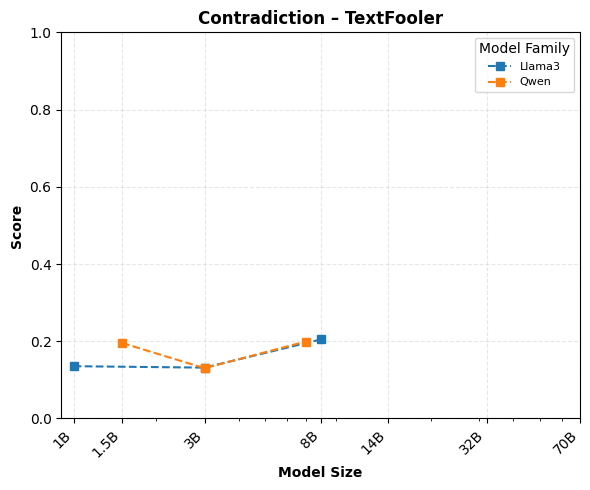


🔹 Processing metric group: fluency
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/fluency_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/fluency_Introspection_Llama3.png


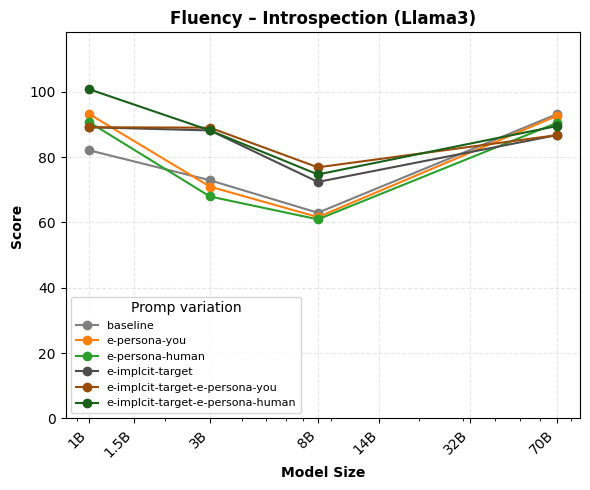

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/fluency_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/fluency_Introspection_Qwen.png


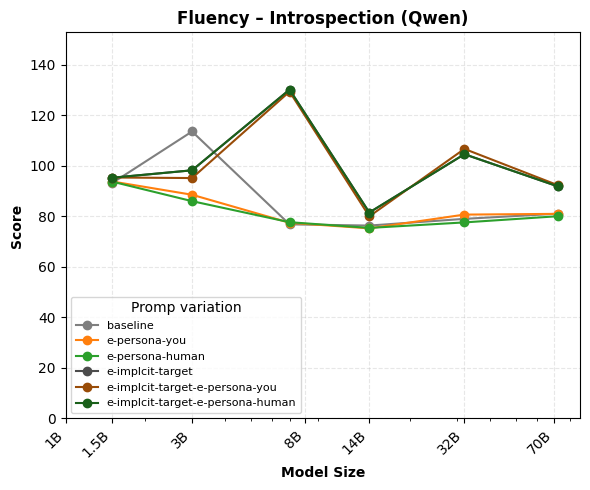

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/fluency_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/fluency_TextFooler.png


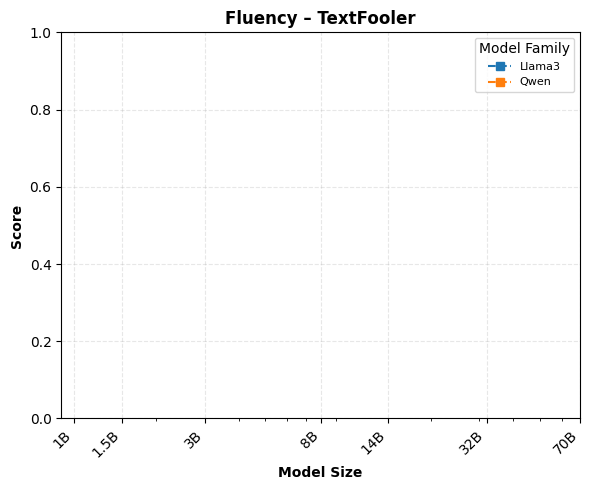


🔹 Processing metric group: diversity
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/diversity_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/diversity_Introspection_Llama3.png


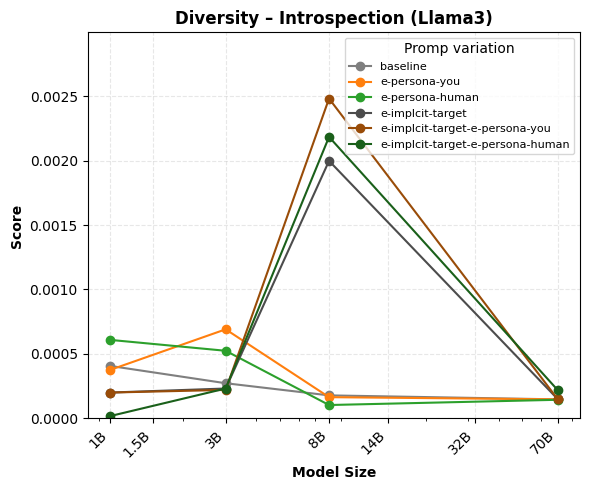

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/diversity_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/diversity_Introspection_Qwen.png


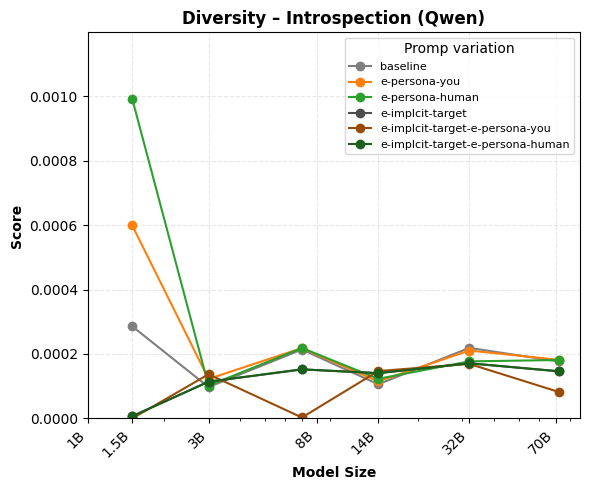

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/diversity_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/diversity_TextFooler.png


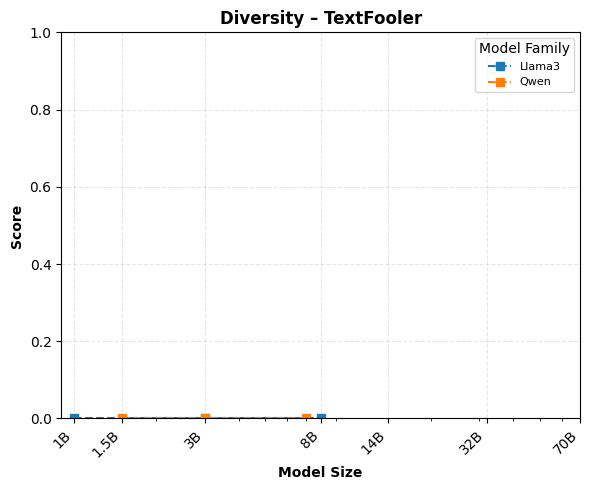


🔹 Processing metric group: evidence_accuracy
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_accuracy_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_accuracy_Introspection_Llama3.png


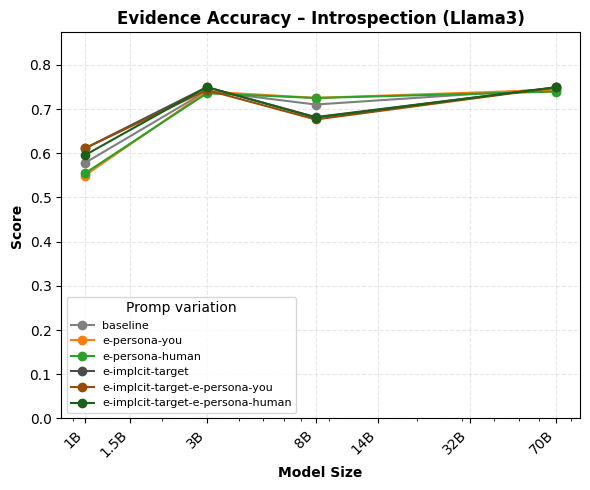

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_accuracy_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_accuracy_Introspection_Qwen.png


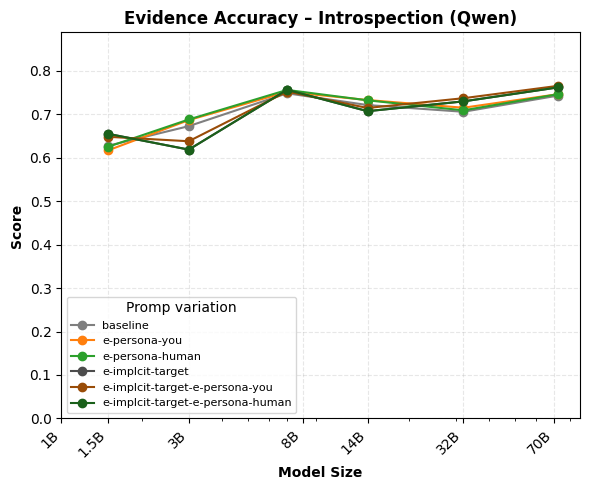

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_accuracy_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_accuracy_TextFooler.png


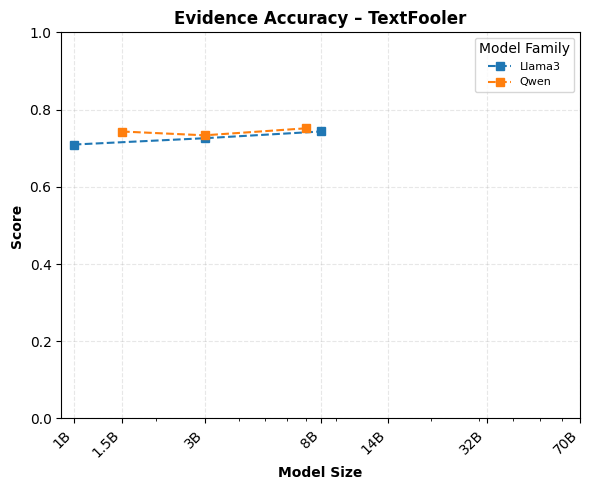


🔹 Processing metric group: evidence_precision
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_precision_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_precision_Introspection_Llama3.png


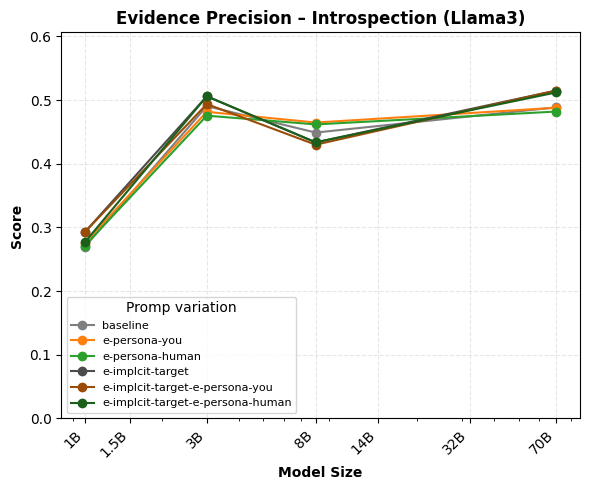

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_precision_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_precision_Introspection_Qwen.png


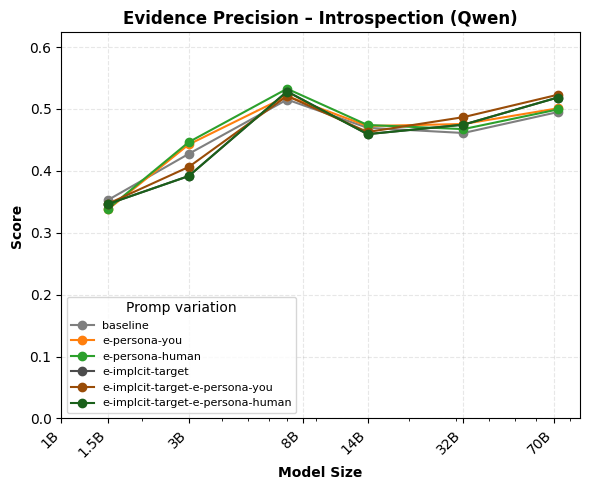

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_precision_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_precision_TextFooler.png


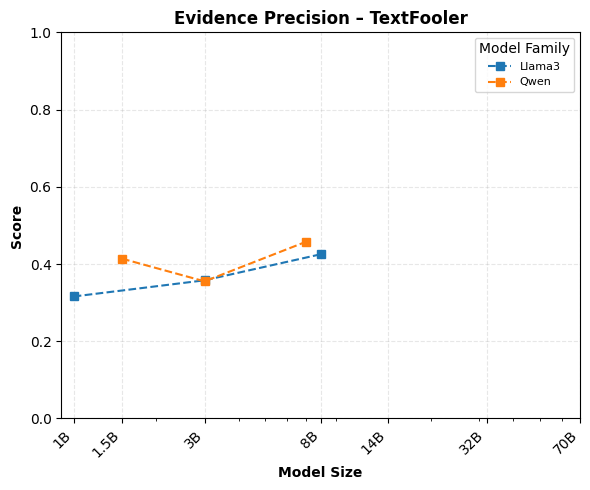


🔹 Processing metric group: evidence_recall
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_recall_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_recall_Introspection_Llama3.png


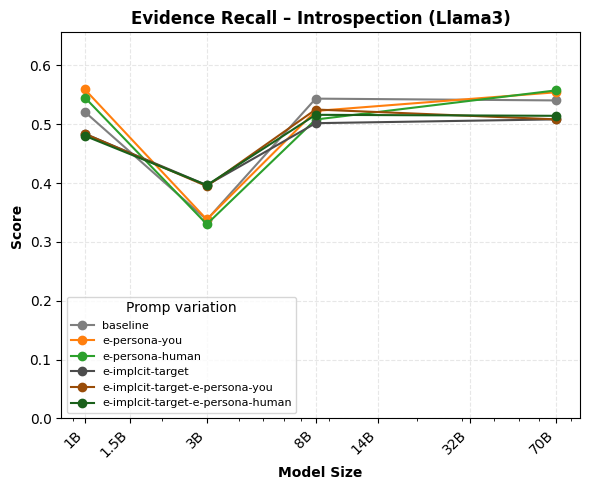

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_recall_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_recall_Introspection_Qwen.png


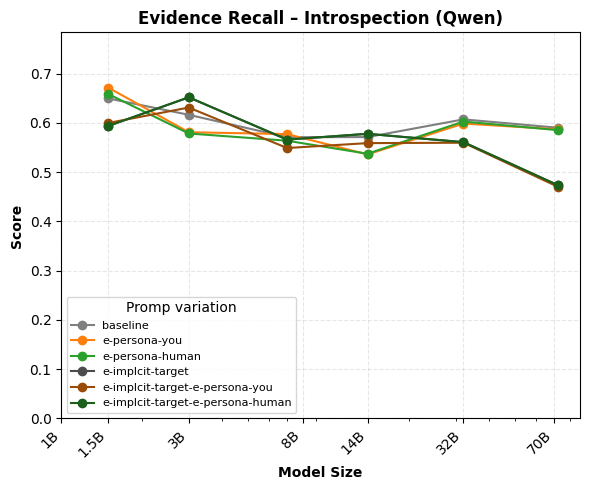

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_recall_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_recall_TextFooler.png


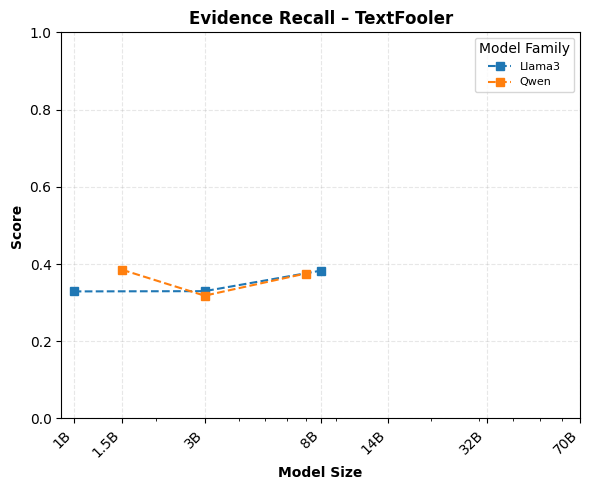


🔹 Processing metric group: evidence_f1
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_f1_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_f1_Introspection_Llama3.png


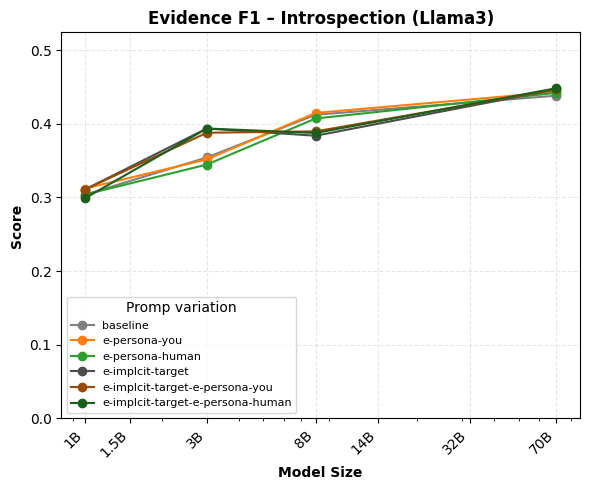

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_f1_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_f1_Introspection_Qwen.png


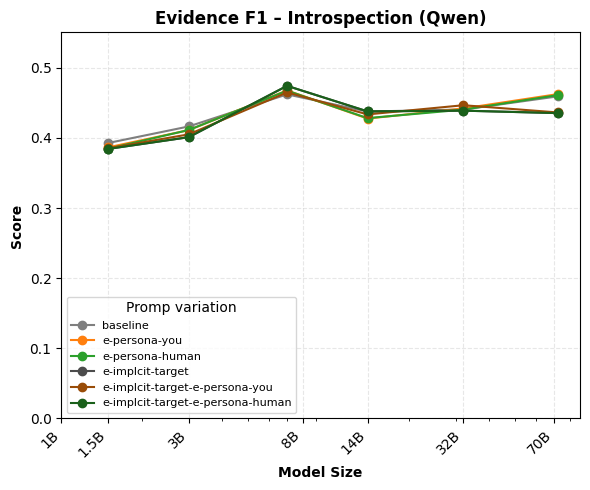

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_f1_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/evidence_f1_TextFooler.png


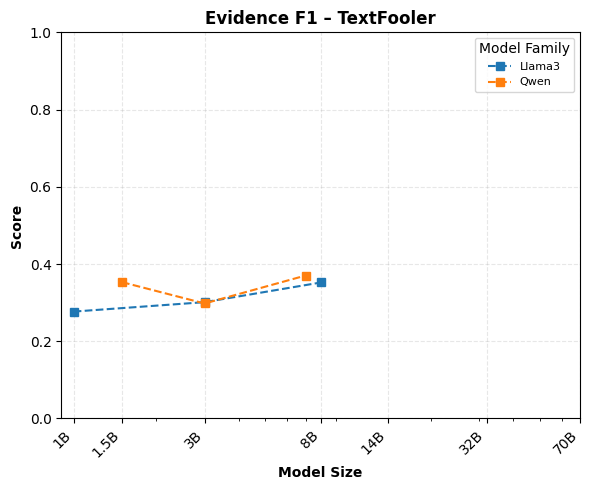


🔹 Processing metric group: crest_accuracy
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_accuracy_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_accuracy_Introspection_Llama3.png


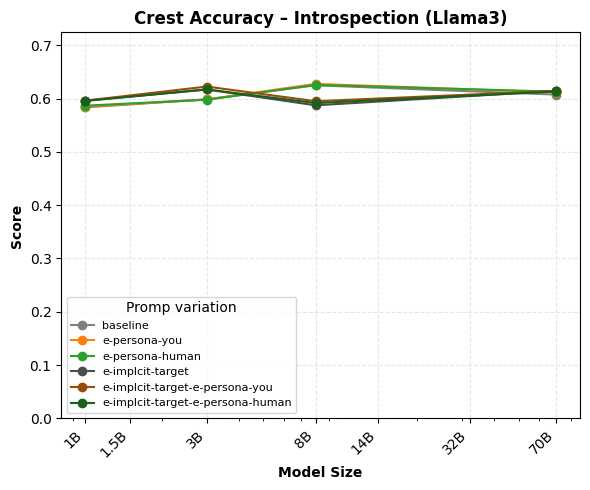

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_accuracy_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_accuracy_Introspection_Qwen.png


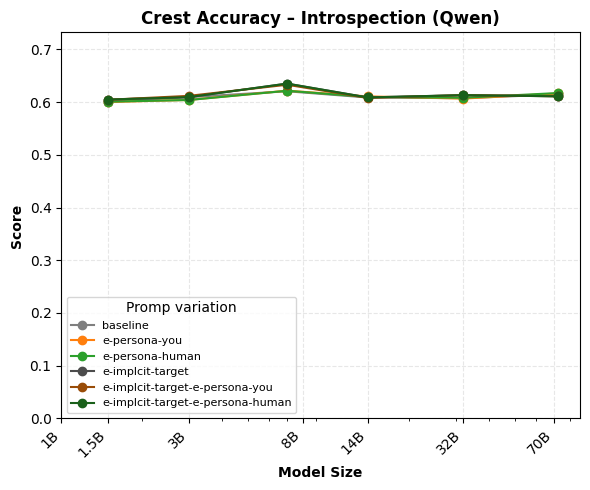

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_accuracy_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_accuracy_TextFooler.png


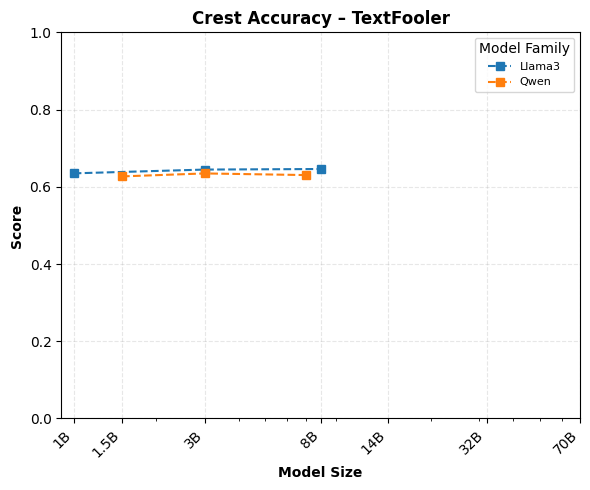


🔹 Processing metric group: crest_precision
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_precision_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_precision_Introspection_Llama3.png


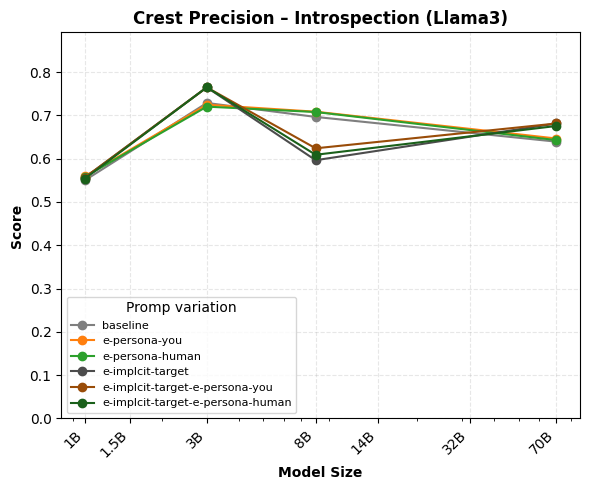

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_precision_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_precision_Introspection_Qwen.png


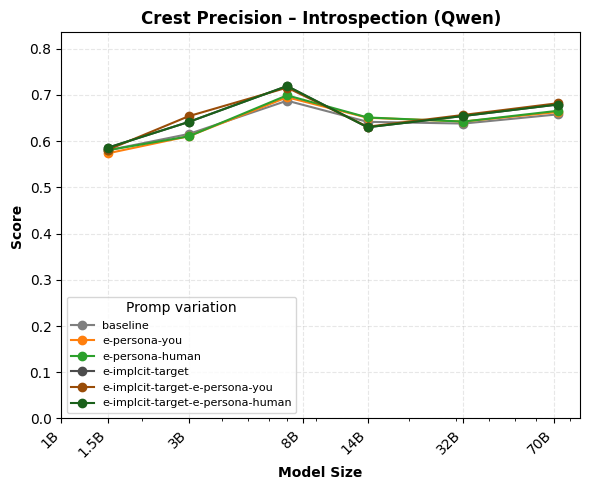

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_precision_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_precision_TextFooler.png


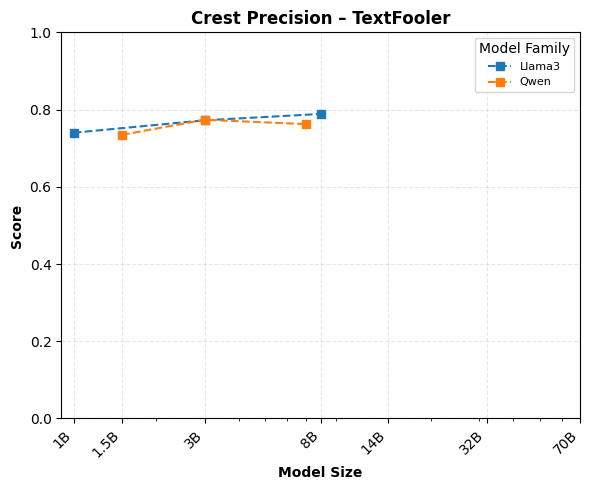


🔹 Processing metric group: crest_recall
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_recall_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_recall_Introspection_Llama3.png


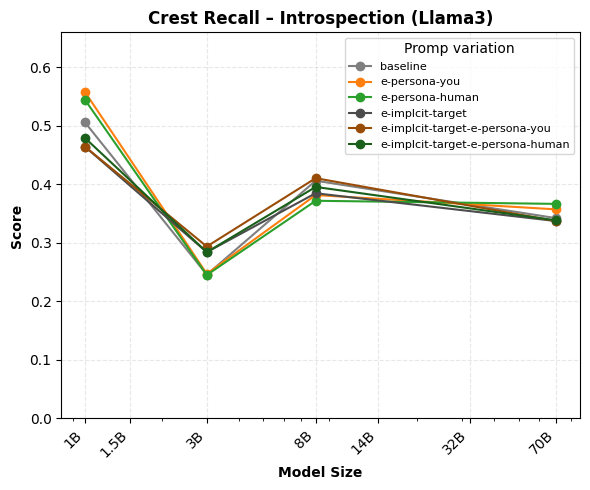

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_recall_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_recall_Introspection_Qwen.png


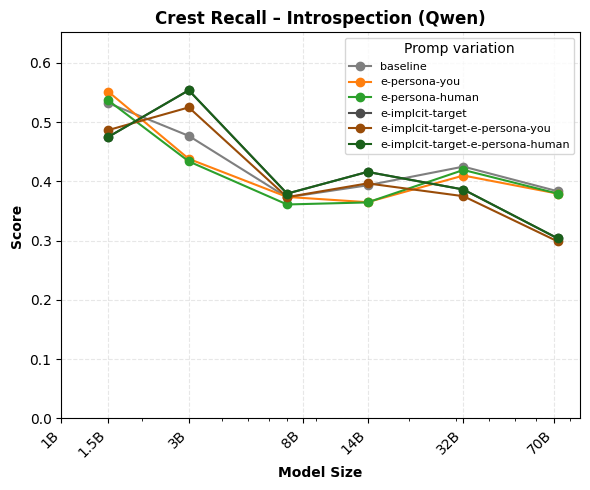

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_recall_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_recall_TextFooler.png


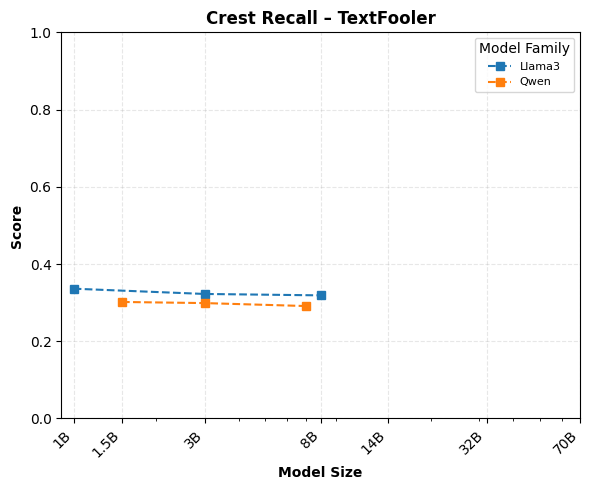


🔹 Processing metric group: crest_f1
   📊 Plotting Introspection for Llama3
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_f1_Introspection_Llama3.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_f1_Introspection_Llama3.png


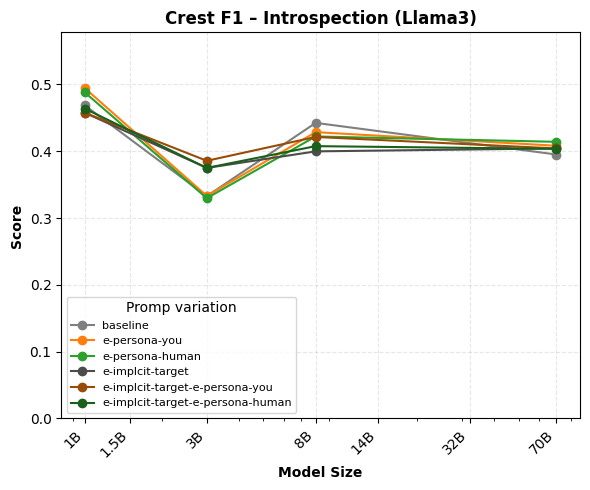

   📊 Plotting Introspection for Qwen
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_f1_Introspection_Qwen.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_f1_Introspection_Qwen.png


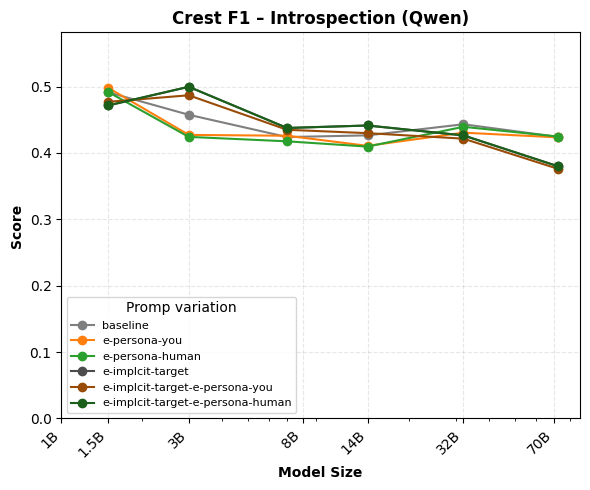

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_f1_TextFooler.png
   ✅ Saved /home/user/Desktop/diploma/results/esnli_results/plots/crest_f1_TextFooler.png


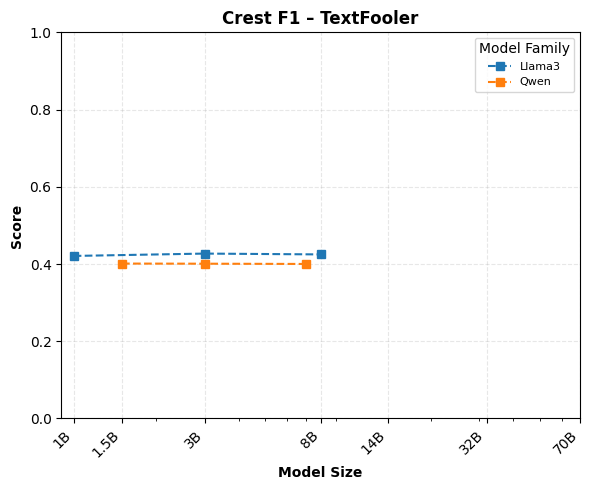

In [5]:
directory = path+'/results/esnli_results/plots'
plot_size_comparison(models, results, directory)